In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.shape

(545, 13)

In [6]:
df.groupby('parking')['price'].mean()

parking
0    4.136017e+06
1    5.190389e+06
2    5.896328e+06
3    5.867167e+06
Name: price, dtype: float64

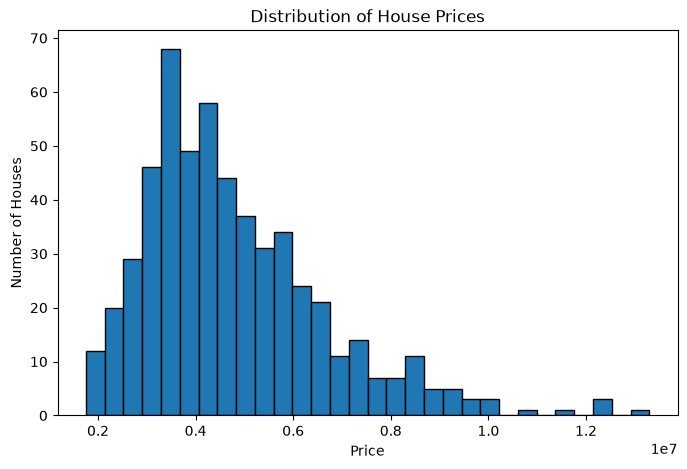

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30, edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.show()

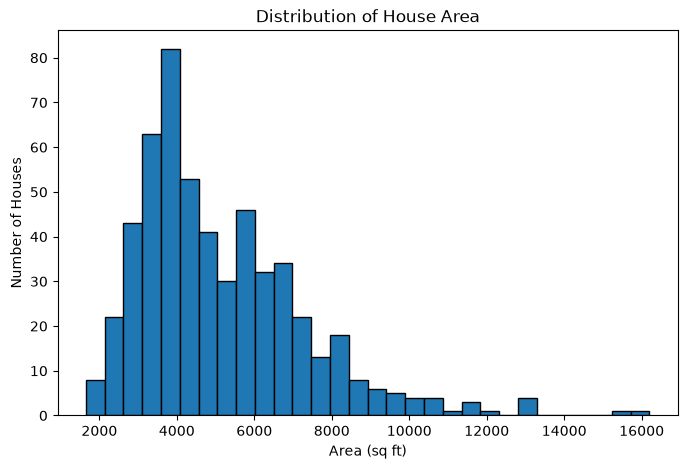

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['area'], bins=30, edgecolor='black')
plt.title('Distribution of House Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Number of Houses')
plt.show()

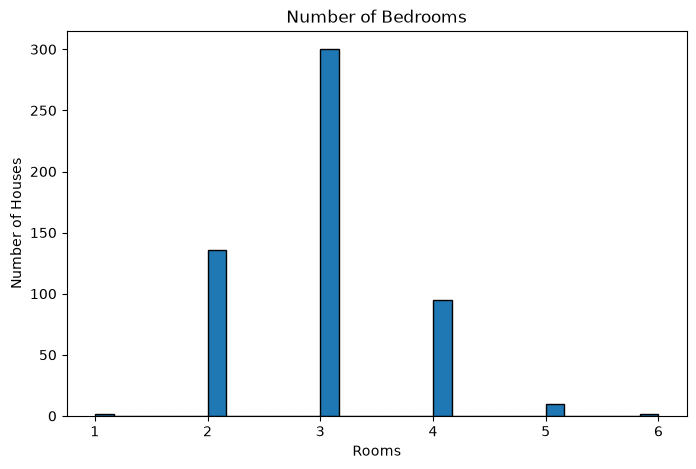

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['bedrooms'], bins=30, edgecolor='black')
plt.title('Number of Bedrooms')
plt.xlabel('Rooms')
plt.ylabel('Number of Houses')
plt.show()

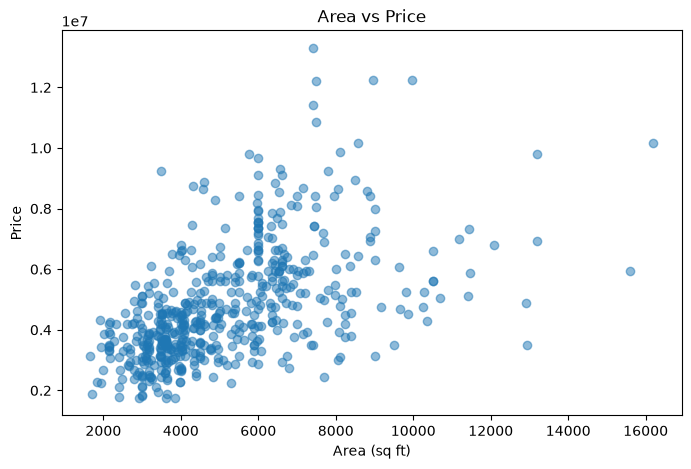

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'], alpha=0.5)
plt.title('Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.show()

In [11]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

In [12]:
df.groupby('airconditioning')['price'].mean()

airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

In [13]:
df.groupby('mainroad')['price'].mean()

mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64

In [14]:
df.groupby('prefarea')['price'].mean()

prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64

In [15]:
df.groupby('guestroom')['price'].mean()

guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

In [16]:
df.groupby('basement')['price'].mean()

basement
no     4.509966e+06
yes    5.242615e+06
Name: price, dtype: float64

In [17]:
df.groupby('hotwaterheating')['price'].mean()

hotwaterheating
no     4.728593e+06
yes    5.559960e+06
Name: price, dtype: float64

In [18]:
df.groupby('furnishingstatus')['price'].mean()

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

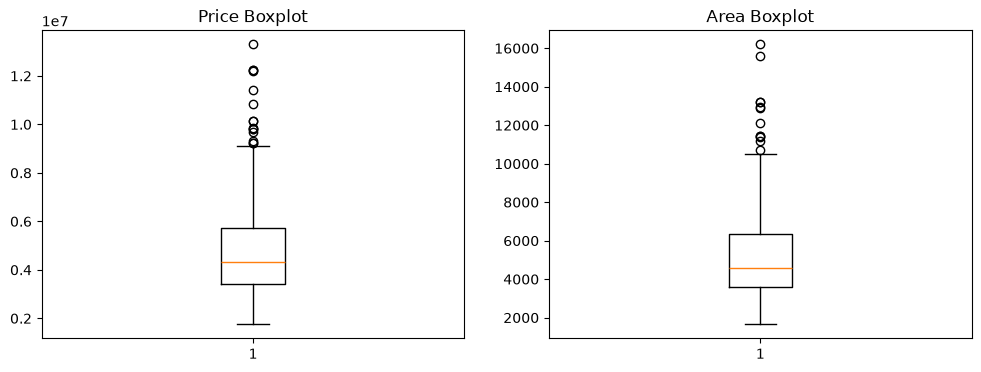

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].boxplot(df['price'])
axes[0].set_title('Price Boxplot')
axes[1].boxplot(df['area'])
axes[1].set_title('Area Boxplot')
plt.show()

In [20]:
df.groupby('guestroom')['price'].mean()

guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

In [21]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({
        'yes': 1,
        'no': 0
    })

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    str  
dtypes: int64(12), str(1)
memory usage: 61.7 KB


In [23]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

In [25]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [26]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,True,False
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,True,False
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,False,True
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,False,False
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,False,True


In [27]:
df.shape

(545, 14)

In [28]:
X = df.drop('price', axis=1)
y = df['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nColumns being used as features:\n{list(X.columns)}")

Features shape: (545, 13)
Target shape: (545,)

Columns being used as features:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 436 samples
Test set: 109 samples


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
print("Before scaling (first row of X_train):")
print(X_train.iloc[0])
print("\nAfter scaling (first row of X_train_scaled):")
print(X_train_scaled[0])

Before scaling (first row of X_train):
area                                6000
bedrooms                               3
bathrooms                              2
stories                                4
mainroad                               1
guestroom                              0
basement                               0
hotwaterheating                        0
airconditioning                        1
parking                                1
prefarea                               0
furnishingstatus_semi-furnished    False
furnishingstatus_unfurnished       False
Name: 46, dtype: object

After scaling (first row of X_train_scaled):
[ 0.38416819  0.05527092  1.53917323  2.58764353  0.40715525 -0.46677307
 -0.74642003 -0.23052136  1.50124327  0.36795665 -0.55262032 -0.870669
 -0.67690027]


In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


In [33]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

print(coefficients)
print(f"\nBase price (intercept): {model.intercept_:,.2f}")

                            Feature         Weight
2                         bathrooms  521879.027748
0                              area  519552.416340
8                   airconditioning  365157.393851
3                           stories  349251.438906
10                         prefarea  266656.351993
9                           parking  192005.953667
6                          basement  187067.803214
7                   hotwaterheating  149862.702991
4                          mainroad  128498.628215
5                         guestroom   88768.667686
1                          bedrooms   57349.559419
11  furnishingstatus_semi-furnished  -62837.321865
12     furnishingstatus_unfurnished -192015.917982

Base price (intercept): 4,706,527.39


In [34]:
y_pred = model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
}).head(10)

print(comparison)

   Actual Price  Predicted Price
0       4060000     5.164654e+06
1       6650000     7.224722e+06
2       3710000     3.109863e+06
3       6440000     4.612075e+06
4       2800000     3.294646e+06
5       4900000     3.532275e+06
6       5250000     5.611775e+06
7       4543000     6.368146e+06
8       2450000     2.722857e+06
9       3353000     2.629406e+06


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹970,043.40
RMSE: ₹1,324,506.96
R²:   0.6529


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  ₹{mae_rf:,.2f}")
print(f"RMSE: ₹{rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

MAE:  ₹1,022,560.05
RMSE: ₹1,401,496.84
R²:   0.6114


In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


In [38]:
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"MAE:  ₹{mae_best_rf:,.2f}")
print(f"RMSE: ₹{rmse_best_rf:,.2f}")
print(f"R²:   {r2_best_rf:.4f}")

MAE:  ₹1,060,413.65
RMSE: ₹1,448,432.87
R²:   0.5849


In [39]:
import joblib

joblib.dump(model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!
